In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Bidirectional, Masking

In [17]:
df_normal = pd.read_csv("ptbdb_normal.csv", header=None)
df_abnormal = pd.read_csv("ptbdb_abnormal.csv", header=None)

df_combined = pd.concat([df_normal, df_abnormal], axis=0, ignore_index=True)

X = df_combined.iloc[:, :-1].values.astype('float32')
y = df_combined.iloc[:, -1].values.astype('float32')

X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

train_df_raw = pd.DataFrame(X_train_raw)
train_df_raw['label'] = y_train_raw

df_train_normal = train_df_raw[train_df_raw['label'] == 0]
df_train_abnormal = train_df_raw[train_df_raw['label'] == 1]

df_normal_upsampled = resample(df_train_normal, replace=True,
                               n_samples=len(df_train_abnormal),
                               random_state=42)

train_balanced = pd.concat([df_normal_upsampled, df_train_abnormal])

X_train = train_balanced.iloc[:, :-1].values
y_train = train_balanced.iloc[:, -1].values

print(f"test set size:  {len(X_test)}")
print(f"training set size(balanced) {len(X_train)}")

test set size:  2911
training set size(balanced) 16808


In [18]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Shape of data for model: {X_train.shape}")

Shape of data for model: (16808, 187, 1)


In [24]:
def build_ptbdb_model(input_shape):
    inputs = Input(shape=input_shape)
    x = Masking(mask_value=0.0)(inputs)

    x = Bidirectional(GRU(128, return_sequences=True))(x)
    x = Bidirectional(GRU(64, return_sequences=False))(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_ptbdb_model((X_train.shape[1], 1))
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, 187, 1)    │          0 │ input_layer_5[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_5 (Masking) │ (None, 187, 1)    │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_5 (Any)         │ (None, 187)       │          0 │ not_equal_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 187, 256)  │    100,608 │ masking_5[0][0],  │
│ (Bidirectional)     │                   │            │ any_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 128)       │    123,648 │ bidirectional_5[… │
│ (Bidirectional)     │                   │            │ any_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     16,512 │ bidirectional_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │         65 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 249,089 (973.00 KB)

 Trainable params: 249,089 (973.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 43s 176ms/step - accuracy: 0.6821 - loss: 0.5957 - val_accuracy: 0.4001 - val_loss: 0.8377 - learning_rate: 5.0000e-04
Epoch 2/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 42s 186ms/step - accuracy: 0.7508 - loss: 0.5235 - val_accuracy: 0.5694 - val_loss: 0.7037 - learning_rate: 5.0000e-04
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 43s 192ms/step - accuracy: 0.7821 - loss: 0.4837 - val_accuracy: 0.6324 - val_loss: 0.6328 - learning_rate: 5.0000e-04
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 44s 197ms/step - accuracy: 0.8127 - loss: 0.4295 - val_accuracy: 0.8164 - val_loss: 0.4068 - learning_rate: 5.0000e-04
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 45s 202ms/step - accuracy: 0.8587 - loss: 0.3518 - val_accuracy: 0.8287 - val_loss: 0.3890 - learning_rate: 5.0000e-04
Epoch 6/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 46s 204ms/step - accuracy: 0.8905 - loss: 0.2861 - val_accuracy: 0.8481 - val_loss: 0.3424 - learning_rate: 5.0000e-04
Epoch 7/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 46s 20

91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step

--- Classification Report (PTBDB) ---
              precision    recall  f1-score   support

      Normal       0.92      0.97      0.94       809
    Abnormal       0.99      0.97      0.98      2102

    accuracy                           0.97      2911
   macro avg       0.95      0.97      0.96      2911
weighted avg       0.97      0.97      0.97      2911



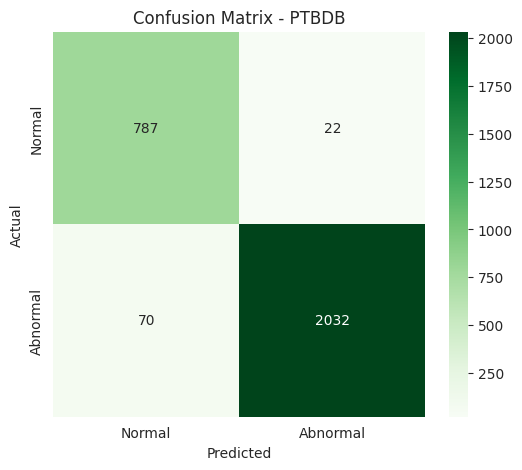

In [26]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print("\n--- Classification Report (PTBDB) ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title('Confusion Matrix - PTBDB')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [27]:
model.save("ECG_Binary_Classifier_97.h5")
print("model saved")

model saved
